### Ejercicio 2 - Diagnostico experimental de CPU, memoria, disco e I/O
## Objetivo. Construir un microbenchmark local en Python para observar diferencias entre operacio-
nes intensivas en CPU, memoria, almacenamiento y entrada/salida. El prop´osito es que el estudiante
conecte arquitectura computacional, jerarqu´ıa de memoria y cuellos de botella con evidencia experi-
mental.

In [3]:
from benchmark import medir, paso_nbody, crear_particulas,simulacion_nbody
from benchmark import benchmark_cpu
from benchmark import benchmark_memoria
from benchmark import benchmark_disco
from benchmark import graficar_cpu, graficar_memoria, graficar_disco
import pandas as pd

## Ejecución del benchmark CPU

Lanzamos el escenario completo del benchmark CPU (simulación N-body):

- **5 tamaños** de `N_PARTICULAS` × **8 repeticiones** = **40 mediciones**.
- Cooldown de 10 s entre repeticiones para mitigar thermal throttling.
- Cada registro contiene tiempo, memoria delta, throughput (pares/s) y la información 
  del tamaño correspondiente.

In [5]:
registros_cpu = benchmark_cpu()
df_cpu = pd.DataFrame(registros_cpu)
df_cpu


[CPU] N = 1500 partículas (1,124,250 pares de cálculos)
  rep 1/8: 0.235 s
  rep 2/8: 0.250 s
  rep 3/8: 0.246 s
  rep 4/8: 0.252 s
  rep 5/8: 0.247 s
  rep 6/8: 0.251 s
  rep 7/8: 0.250 s
  rep 8/8: 0.245 s

[CPU] N = 2000 partículas (1,999,000 pares de cálculos)
  rep 1/8: 0.423 s
  rep 2/8: 0.416 s
  rep 3/8: 0.418 s
  rep 4/8: 0.430 s
  rep 5/8: 0.422 s
  rep 6/8: 0.415 s
  rep 7/8: 0.415 s
  rep 8/8: 0.416 s

[CPU] N = 2800 partículas (3,918,600 pares de cálculos)
  rep 1/8: 0.780 s
  rep 2/8: 0.790 s
  rep 3/8: 0.783 s
  rep 4/8: 0.791 s
  rep 5/8: 0.795 s
  rep 6/8: 0.793 s
  rep 7/8: 0.788 s
  rep 8/8: 0.791 s

[CPU] N = 4000 partículas (7,998,000 pares de cálculos)
  rep 1/8: 1.584 s
  rep 2/8: 1.580 s
  rep 3/8: 1.591 s
  rep 4/8: 1.598 s
  rep 5/8: 1.588 s
  rep 6/8: 1.589 s
  rep 7/8: 1.586 s
  rep 8/8: 1.611 s

[CPU] N = 5500 partículas (15,122,250 pares de cálculos)
  rep 1/8: 3.011 s
  rep 2/8: 3.011 s
  rep 3/8: 3.019 s
  rep 4/8: 3.007 s
  rep 5/8: 3.061 s
  rep 6/8: 

,escenario,tamano_n,tamano_pares,repeticion,tiempo_s,memoria_delta_mb,throughput_pares_s
0,cpu_nbody,1500,1124250,1,0.234934,0.562500,4.785381e+06
1,cpu_nbody,1500,1124250,2,0.249598,0.515625,4.504250e+06
2,cpu_nbody,1500,1124250,3,0.245876,0.000000,4.572431e+06
3,cpu_nbody,1500,1124250,4,0.251762,0.000000,4.465531e+06
4,cpu_nbody,1500,1124250,5,0.247452,0.000000,4.543300e+06
5,cpu_nbody,1500,1124250,6,0.251051,0.000000,4.478167e+06
6,cpu_nbody,1500,1124250,7,0.249909,0.000000,4.498633e+06
7,cpu_nbody,1500,1124250,8,0.245466,0.000000,4.580062e+06
8,cpu_nbody,2000,1999000,1,0.422634,0.234375,4.729865e+06
9,cpu_nbody,2000,1999000,2,0.415774,0.187500,4.807899e+06


### 1. Throughput aproximadamente estable entre tamaños

El throughput medido se mantiene en un rango estrecho (~4.5 – 5.05 millones de 
pares/s) a lo largo de los cinco tamaños probados. Aunque el trabajo total crece 
13× entre el N más chico (1500) y el más grande (5500), el throughput varía menos 
de 12%. Esa relativa invariancia respecto al tamaño es consistente con la firma 
de una tarea **CPU-bound**: la velocidad efectiva la dicta la capacidad aritmética 
del procesador, no el ancho de banda de memoria ni el almacenamiento.

Se observa un leve incremento del throughput con N (de ~4.5 M/s en N=1500 a 
~5.0 M/s en N=5500). Esto puede atribuirse a que la sobrecarga constante de cada 
iteración del bucle (llamadas a función, accesos a diccionarios) representa una 
fracción mayor del tiempo total cuando N es pequeño.

### 2. El tiempo escala de forma compatible con O(N²)

Pasar de N=1500 a N=5500 implica un factor 3.67× en el número de partículas. 
La complejidad teórica O(N²) predeciría un aumento de tiempo de 3.67² ≈ 13.5×. 
El factor observado es 3.03 / 0.25 ≈ 12.1×, una discrepancia de aproximadamente 
10% respecto a lo teórico — atribuible a la sobrecarga constante mencionada arriba. 
Esto **sugiere** (no demuestra de forma absoluta) que la implementación efectiva 
del algoritmo se comporta como predice el análisis asintótico.

### 3. Reproducibilidad interna alta

Las 8 repeticiones de cada tamaño exhiben desviación estándar típicamente menor 
al 3% del promedio. Esto sugiere que:

- El cooldown de 10 s entre repeticiones fue efectivo para evitar thermal 
  throttling en una máquina de refrigeración pasiva (MacBook Air M4 sin ventilador).
- La carga externa del sistema se mantuvo estable durante los ~7 minutos de la 
  corrida.

Nuevamente, esto es lo observado en **esta corrida puntual**; otra ejecución 
con apps pesadas abiertas podría producir mayor variabilidad.

### 4. Uso de memoria marginal

La mayoría de las mediciones reportan `memoria_delta_mb` cercano a 0, con 
ocasionales valores pequeños (< 1 MB) en la primera repetición de cada tamaño 
(asignación inicial de la lista de partículas). Esto es coherente con la 
naturaleza del experimento: ~5500 dicts de Python ocupan apenas ~150 KB, y el 
algoritmo no asigna estructuras grandes durante el cómputo. Confirma que el 
cuello de botella en este escenario **no** es la memoria.

### Limitaciones de estas observaciones

- Los valores absolutos son específicos del hardware y software utilizados. 
  La misma implementación correrá distinto en una CPU x86, en una CPU más vieja 
  o más nueva, en otro intérprete de Python (PyPy, por ejemplo) o bajo distinta 
  carga concurrente.
- El experimento no aísla qué porción del tiempo corresponde a aritmética pura 
  vs control de flujo vs overhead del intérprete CPython. Para esa atribución se 
  requeriría perfilado más fino (cProfile, py-spy, Instruments).
- No se midió la temperatura del chip directamente; el cooldown de 10 s es una 
  heurística razonable pero no una garantía absoluta de estabilidad térmica.

## Ejecución del benchmark de memoria

Lanzamos el escenario completo de memoria (matriz 2D con acceso por filas vs columnas):

- **5 tamaños** de matriz (lado N: 500, 1200, 2800, 6000, 11000) × **2 patrones de 
  acceso** (filas, columnas) × **8 repeticiones** = **80 mediciones** en total.
- Para cada tamaño, la matriz se asigna **una sola vez** (afuera de `medir`) y se 
  reusa para los dos patrones, garantizando que la única diferencia entre filas y 
  columnas es el orden de acceso, no la asignación.
- Cooldown de 10 s entre cada repetición.

Tiempo de ejecución real: **~13 min 14 s**.

In [ ]:
registros_mem = benchmark_memoria()
df_mem = pd.DataFrame(registros_mem)
df_mem


[MEM] Matriz 500×500  (250,000 elementos, 1.9 MB)
  Acceso por filas (secuencial en memoria):
    rep 1/8: 0.0004 s
    rep 2/8: 0.0021 s
    rep 3/8: 0.0021 s
    rep 4/8: 0.0020 s
    rep 5/8: 0.0008 s
    rep 6/8: 0.0007 s
    rep 7/8: 0.0011 s
    rep 8/8: 0.0006 s
  Acceso por columnas (con saltos en memoria):
    rep 1/8: 0.0017 s
    rep 2/8: 0.0024 s
    rep 3/8: 0.0016 s
    rep 4/8: 0.0017 s
    rep 5/8: 0.0025 s
    rep 6/8: 0.0015 s
    rep 7/8: 0.0015 s
    rep 8/8: 0.0016 s

[MEM] Matriz 1200×1200  (1,440,000 elementos, 11.0 MB)
  Acceso por filas (secuencial en memoria):
    rep 1/8: 0.0009 s
    rep 2/8: 0.0042 s
    rep 3/8: 0.0056 s
    rep 4/8: 0.0041 s
    rep 5/8: 0.0056 s
    rep 6/8: 0.0045 s
    rep 7/8: 0.0041 s
    rep 8/8: 0.0042 s
  Acceso por columnas (con saltos en memoria):
    rep 1/8: 0.0071 s
    rep 2/8: 0.0077 s
    rep 3/8: 0.0077 s
    rep 4/8: 0.0070 s
    rep 5/8: 0.0072 s
    rep 6/8: 0.0054 s
    rep 7/8: 0.0055 s
    rep 8/8: 0.0072 s

[MEM] 

,escenario,tamano_n,tamano_elementos,tamano_mb,repeticion,tiempo_s,memoria_delta_mb,throughput_mb_s
0,memoria_filas,500,250000,1.907349,1,0.000380,0.0,5013.296105
1,memoria_filas,500,250000,1.907349,2,0.002068,0.0,922.296849
2,memoria_filas,500,250000,1.907349,3,0.002071,0.0,921.035130
3,memoria_filas,500,250000,1.907349,4,0.001973,0.0,966.949568
4,memoria_filas,500,250000,1.907349,5,0.000806,0.0,2365.337014
...,...,...,...,...,...,...,...,...
75,memoria_columnas,11000,121000000,923.156738,4,0.212538,0.0,4343.482622
76,memoria_columnas,11000,121000000,923.156738,5,0.212836,0.0,4337.400317
77,memoria_columnas,11000,121000000,923.156738,6,0.207585,0.0,4447.129978
78,memoria_columnas,11000,121000000,923.156738,7,0.214194,0.0,4309.906905


### 1. Acceso por filas es sistemáticamente más rápido que por columnas

Resumen del throughput promedio (en MB/s) por tamaño:

| Lado N | Tamaño | Filas | Columnas | Ratio F/C |
|--------|--------|-------|----------|-----------|
| 500 | 1.9 MB | 2237 | 1084 | **2.06×** |
| 1200 | 11 MB | 3609 | 1630 | **2.21×** |
| 2800 | 60 MB | 7695 | 2667 | **2.88×** |
| 6000 | 275 MB | 10364 | 3079 | **3.37×** |
| 11000 | 923 MB | 16680 | 4376 | **3.81×** |

En todos los tamaños probados, el acceso por filas (que recorre la memoria de 
forma contigua, dado que numpy almacena matrices en orden row-major) supera al 
acceso por columnas (que salta `N × 8` bytes entre cada lectura, causando 
*cache misses* en cada acceso).

### 2. El gap entre filas y columnas crece con el tamaño

El ratio filas/columnas aumenta sistemáticamente de **~2.0×** a **~3.8×** al 
pasar de 1.9 MB a 923 MB. Una posible explicación es que, para matrices que 
caben holgadamente en la caché L2 del procesador (≈ 16 MB en el M4), la 
caché absorbe gran parte de la penalización del acceso no-contiguo; una vez 
que la matriz excede esa capacidad, la penalización se materializa porque cada 
acceso aleatorio fuerza una carga desde RAM. Esta observación es **consistente** 
con la teoría de la jerarquía de memoria descrita en bibliografía, aunque el 
experimento no la **prueba de forma absoluta** (no se midió la temperatura del 
chip, ni se forzó la eviction de cache, ni se aislaron otros procesos del 
sistema).

### 3. La variabilidad cae con el tamaño — para ambos patrones

Coeficiente de variación (CV = std/mean, en porcentaje) por tamaño:

| Lado N | Tamaño | CV filas | CV columnas |
|--------|--------|----------|-------------|
| 500 | 1.9 MB | **63.6%** | 18.5% |
| 1200 | 11 MB | **94.5%** | 14.7% |
| 2800 | 60 MB | **81.3%** | 25.2% |
| 6000 | 275 MB | 14.7% | 4.5% |
| 11000 | 923 MB | 20.3% | 1.7% |

Para tamaños pequeños (< 60 MB), la variabilidad en filas es enorme (hasta 
94.5%). Esto se debe a que el tiempo total de la operación cae a milisegundos 
o menos, y a esa escala el **overhead del intérprete Python** (el bucle `for` 
externo, las llamadas a `.sum()`, eventuales pausas del *garbage collector*) 
es comparable al trabajo real. Las mediciones en ese régimen están dominadas 
por ruido de software, no por velocidad de memoria.

A partir de 275 MB la CV baja drásticamente porque el trabajo de la operación 
en sí pasa a dominar el tiempo total.

### 4. El uso de memoria reportado por `medir` es cero o casi cero

Todas las filas muestran `memoria_delta_mb` cercano a 0. Esto es **esperado** 
y deseable: la matriz (de hasta ~1 GB) se asigna **antes** de invocar a `medir`, 
por lo que la asignación grande no entra en la medición. Lo que se mide es 
únicamente el costo de recorrer un array ya existente — exactamente lo que 
quisimos aislar.

### 5. El throughput crece con el tamaño en ambos patrones (efecto secundario)

Observe que el throughput aumenta de forma monótona con el tamaño, tanto en 
filas (2237 → 16680 MB/s) como en columnas (1084 → 4376 MB/s). Para arrays 
grandes, el costo del bucle externo en Python se diluye y el trabajo "útil" 
(sumar bytes de RAM) domina; por eso el throughput observado se aproxima a 
la velocidad real de acceso. Para arrays chicos, el "tiempo" reportado 
incluye una fracción significativa de overhead de software, deprimiendo el 
throughput aparente.

### Limitaciones de estas observaciones

- Los throughputs absolutos son hardware-dependientes. Una CPU con caché L3 
  más grande, o una RAM con menor latencia, daría números distintos.
- No se midió directamente el número de *cache misses* (haría falta `perf` en 
  Linux o `Instruments` en macOS). La interpretación en términos de caché L2 
  vs RAM es plausible pero no demostrada por esta corrida.
- El factor 3.8× observado en el tamaño grande es modesto comparado con lo que 
  se reporta en bibliografía clásica (10-100×) para máquinas previas a Apple 
  Silicon. Esto **sugiere** que los *prefetchers* y la SLC (System-Level Cache) 
  del M4 mitigan parte de la penalización del acceso no-contiguo, pero requiere 
  estudios adicionales para confirmarlo.
- Los tamaños pequeños (< 60 MB) están contaminados por overhead de Python y 
  no son útiles para conclusiones sobre velocidad de memoria; su utilidad es 
  marcar el **límite inferior** del método.

In [7]:
resumen_mem = df_mem.groupby(['escenario', 'tamano_n']).agg(
    n_reps=('tiempo_s', 'count'),
    tiempo_mean=('tiempo_s', 'mean'),
    tiempo_std=('tiempo_s', 'std'),
    throughput_mean_mb_s=('throughput_mb_s', 'mean'),
    throughput_std=('throughput_mb_s', 'std'),
).reset_index()
resumen_mem

,escenario,tamano_n,n_reps,tiempo_mean,tiempo_std,throughput_mean_mb_s,throughput_std
0,memoria_columnas,500,8,0.001825,0.000405,1084.070402,200.353550
1,memoria_columnas,1200,8,0.006853,0.000889,1630.235932,238.903035
2,memoria_columnas,2800,8,0.023592,0.005384,2667.466030,672.479813
3,memoria_columnas,6000,8,0.089357,0.004056,3079.243490,139.337268
4,memoria_columnas,11000,8,0.210991,0.003585,4376.435445,74.302714
5,memoria_filas,500,8,0.001207,0.000713,2237.137283,1422.881775
6,memoria_filas,1200,8,0.004174,0.001457,3608.503012,3410.445937
7,memoria_filas,2800,8,0.009921,0.003084,7695.274220,6257.636655
8,memoria_filas,6000,8,0.026979,0.003745,10364.229480,1524.211257
9,memoria_filas,11000,8,0.057997,0.015552,16680.283527,3380.694403


## Ejecución del benchmark de disco

Lanzamos el escenario completo de disco (escritura y lectura en formato binario y CSV):

- **Binario** (`.npy`): 4 tamaños [2500, 4000, 6000, 8000 MB] × 2 operaciones (escritura, lectura) × 8 repeticiones = **64 mediciones**.
  - Los tamaños grandes (> 4 GB) buscan exceder la capacidad del *page cache* disponible 
    en una máquina de 16 GB, para que las lecturas reflejen la velocidad real del SSD y 
    no de la RAM cacheada.
- **CSV**: 4 tamaños chicos [200, 400, 600, 800 MB] × 2 operaciones × 8 repeticiones = **64 mediciones**.
  - Se mantienen tamaños chicos porque la serialización a texto es CPU-bound y crece 
    rápidamente con N (un CSV de 8 GB tardaría horas).
- **Total**: 128 mediciones en una sola corrida.
- Los archivos temporales se crean en `temp_benchmark_disco/` y se eliminan automáticamente 
  al final del benchmark mediante un bloque `finally`, dejando el sistema limpio.
- Cooldown de 10 s entre cada repetición.

Tiempo de ejecución real: **~50 min 51 s**. El cooldown contribuye con la mayor parte del 
tiempo total; el cómputo de las 128 mediciones suma unos ~30 min.

In [8]:
registros_disco = benchmark_disco()
df_disco = pd.DataFrame(registros_disco)
df_disco


[DISCO-BINARIO] 2500 MB (327,680,000 float64)
  Escritura:
    rep 1/8: 1.144 s
    rep 2/8: 1.132 s
    rep 3/8: 1.113 s
    rep 4/8: 1.133 s
    rep 5/8: 1.181 s
    rep 6/8: 1.111 s
    rep 7/8: 1.132 s
    rep 8/8: 1.114 s
  Lectura:
    rep 1/8: 1.171 s
    rep 2/8: 0.867 s
    rep 3/8: 1.055 s
    rep 4/8: 0.957 s
    rep 5/8: 0.880 s
    rep 6/8: 0.997 s
    rep 7/8: 1.036 s
    rep 8/8: 0.903 s

[DISCO-BINARIO] 4000 MB (524,288,000 float64)
  Escritura:
    rep 1/8: 2.555 s
    rep 2/8: 2.467 s
    rep 3/8: 1.888 s
    rep 4/8: 1.876 s
    rep 5/8: 1.884 s
    rep 6/8: 1.900 s
    rep 7/8: 1.943 s
    rep 8/8: 1.876 s
  Lectura:
    rep 1/8: 1.886 s
    rep 2/8: 2.747 s
    rep 3/8: 6.468 s
    rep 4/8: 2.141 s
    rep 5/8: 1.862 s
    rep 6/8: 2.090 s
    rep 7/8: 1.895 s
    rep 8/8: 1.925 s

[DISCO-BINARIO] 6000 MB (786,432,000 float64)
  Escritura:
    rep 1/8: 3.227 s
    rep 2/8: 3.642 s
    rep 3/8: 3.219 s
    rep 4/8: 3.217 s
    rep 5/8: 3.294 s
    rep 6/8: 3.238 s


,escenario,tamano_mb,repeticion,tiempo_s,memoria_delta_mb,throughput_mb_s
0,disco_escritura_binario,2500,1,1.144142,-147.468750,2185.042987
1,disco_escritura_binario,2500,2,1.132076,0.000000,2208.333196
2,disco_escritura_binario,2500,3,1.112665,-781.593750,2246.857517
3,disco_escritura_binario,2500,4,1.133212,0.000000,2206.117807
4,disco_escritura_binario,2500,5,1.180629,0.000000,2117.514503
...,...,...,...,...,...,...
123,disco_lectura_csv,800,4,14.326821,800.015625,55.839324
124,disco_lectura_csv,800,5,14.362381,800.015625,55.701070
125,disco_lectura_csv,800,6,14.520113,-1049.796875,55.095990
126,disco_lectura_csv,800,7,14.474974,-1289.734375,55.267801


## Resumen estadístico del escenario disco

Agregamos las **128 mediciones individuales** del escenario disco en promedio + 
desviación estándar por combinación de `escenario × tamano_mb`. El resultado son 
**16 filas**: 4 tamaños de binario × 2 operaciones + 4 tamaños de CSV × 2 operaciones.

Esta tabla resumen es la base para los gráficos posteriores y para la discusión 
de resultados del escenario disco.

In [9]:
resumen_disco = df_disco.groupby(['escenario', 'tamano_mb']).agg(
    n_reps=('tiempo_s', 'count'),
    tiempo_mean=('tiempo_s', 'mean'),
    tiempo_std=('tiempo_s', 'std'),
    throughput_mean_mb_s=('throughput_mb_s', 'mean'),
    throughput_std=('throughput_mb_s', 'std'),
).reset_index()
resumen_disco

,escenario,tamano_mb,n_reps,tiempo_mean,tiempo_std,throughput_mean_mb_s,throughput_std
0,disco_escritura_binario,2500,8,1.132392,0.022863,2208.487488,43.668645
1,disco_escritura_binario,4000,8,2.048829,0.287230,1981.946245,241.506817
2,disco_escritura_binario,6000,8,3.293406,0.143302,1824.604441,73.092730
3,disco_escritura_binario,8000,8,4.923776,0.279261,1628.863725,82.504362
4,disco_escritura_csv,200,8,15.707319,0.093590,12.733311,0.075530
5,disco_escritura_csv,400,8,31.785567,0.206476,12.584790,0.081266
6,disco_escritura_csv,600,8,47.691865,0.098696,12.580809,0.026070
7,disco_escritura_csv,800,8,63.700600,0.227764,12.558892,0.045109
8,disco_lectura_binario,2500,8,0.983207,0.103152,2566.382126,259.126474
9,disco_lectura_binario,4000,8,2.626616,1.579127,1789.425459,524.975176


### 1. Binario: el throughput decrece a medida que el archivo crece

En escritura binaria (`disco_escritura_binario`):

| Tamaño | Throughput | Std relativo |
|--------|-----------|--------------|
| 2500 MB | 2208 MB/s | 2.0% |
| 4000 MB | 1982 MB/s | 12.2% |
| 6000 MB | 1825 MB/s | 4.0% |
| 8000 MB | 1629 MB/s | 5.1% |

El throughput cae aproximadamente 26% al pasar de 2.5 GB a 8 GB. Una posible 
explicación es que con archivos pequeños el sistema operativo aprovecha el 
**write buffer del kernel** (la escritura "se confirma" como completa antes de 
que los datos toquen el SSD físico), mientras que con archivos grandes el buffer 
se satura y el throughput observado se acerca a la velocidad sostenida real del 
SSD. **No es posible afirmar con este experimento un valor único para "la 
velocidad del SSD"**; lo que sí puede afirmarse es que para archivos > 4 GB, 
el throughput se estabiliza en el rango ~1.6-1.8 GB/s en este equipo.

En lectura binaria (`disco_lectura_binario`) se observa una caída similar 
pero más pronunciada: de 2566 MB/s a 1068 MB/s. La **variabilidad** (`std`) 
también es notablemente mayor en lecturas que en escrituras (CV de 10-60% vs 
2-12% en escrituras). Esa variabilidad sugiere la influencia del **page cache** 
del sistema operativo: algunas repeticiones leen total o parcialmente desde 
RAM (cuando partes del archivo están cacheadas), otras desde el SSD físico. 
En el archivo más grande (8 GB), que excede más claramente la capacidad de 
cache disponible, la variabilidad disminuye, sugiriendo lectura más consistente 
desde el SSD.

### 2. CSV: throughput constante independiente del tamaño

En escritura CSV (`disco_escritura_csv`):

| Tamaño | Throughput | Std relativo |
|--------|-----------|--------------|
| 200 MB | 12.73 MB/s | 0.6% |
| 400 MB | 12.58 MB/s | 0.6% |
| 600 MB | 12.58 MB/s | 0.2% |
| 800 MB | 12.56 MB/s | 0.4% |

El throughput es **prácticamente constante** (~12.5-12.7 MB/s) y la desviación 
estándar es minúscula (< 1% en todos los casos). En lectura CSV se observa el 
mismo patrón con throughput ~55-57 MB/s.

Esta invariancia respecto al tamaño del archivo es la firma característica de 
una operación **CPU-bound**: el SSD podría sostener escrituras más de 100× más 
rápidas, pero la CPU está saturada serializando números a texto (en escritura) 
o parseando texto a números (en lectura). Cambiar el tamaño del archivo no 
cambia el tiempo por byte: cada número se procesa al mismo costo de CPU.

La asimetría entre escritura (~12.5 MB/s) y lectura (~55 MB/s) — relación ≈ 4.5× — 
sugiere que parsear texto a números es menos costoso que el inverso (formatear 
números a texto requiere conversión, redondeo, formato de punto flotante, 
padding, etc.).

### 3. La diferencia entre formatos es de dos órdenes de magnitud

Comparando los promedios:

- Binario, escritura, archivos grandes: ~1.6 GB/s
- CSV, escritura: ~12.5 MB/s
- **Relación aproximada: 130×**

Esta diferencia no es atribuible al dispositivo de almacenamiento (es el mismo 
SSD en ambos casos), sino al **costo de la serialización a texto**. Esto motiva 
empíricamente la elección de formatos columnares binarios (como Apache Parquet, 
adoptado en el Ejercicio 4 de esta evaluación) sobre CSV en pipelines de datos 
a gran escala.

### Limitaciones de estas observaciones

- El page cache de macOS no fue limpiado entre operaciones (haría falta `sudo 
  purge`, que comprometería la reproducibilidad del experimento). En 
  consecuencia, las mediciones de lectura están sistemáticamente sesgadas hacia 
  arriba respecto a la velocidad pura del SSD, especialmente en archivos que 
  caben en el cache disponible.
- La velocidad real del SSD en este equipo solo puede estimarse con archivos 
  suficientemente grandes (> 4 GB en una máquina de 16 GB de RAM). Para otros 
  equipos, el umbral cambiará en función de la RAM disponible.

In [10]:
df_completo = pd.concat([df_cpu, df_mem, df_disco], ignore_index=True)

# Guardado en la misma carpeta que el notebook
df_completo.to_csv("resultados_benchmark.csv", index=False)

print(f"Guardado: {len(df_completo)} filas en resultados_benchmark.csv")
print(f"Escenarios: {df_completo['escenario'].unique()}")
df_completo.head()

Guardado: 248 filas en resultados_benchmark.csv
Escenarios: <StringArray>
[              'cpu_nbody',           'memoria_filas',
        'memoria_columnas', 'disco_escritura_binario',
   'disco_lectura_binario',     'disco_escritura_csv',
       'disco_lectura_csv']
Length: 7, dtype: str


,escenario,tamano_n,tamano_pares,repeticion,tiempo_s,memoria_delta_mb,throughput_pares_s,tamano_elementos,tamano_mb,throughput_mb_s
0,cpu_nbody,1500.0,1124250.0,1,0.234934,0.562500,4.785381e+06,NaN,NaN,NaN
1,cpu_nbody,1500.0,1124250.0,2,0.249598,0.515625,4.504250e+06,NaN,NaN,NaN
2,cpu_nbody,1500.0,1124250.0,3,0.245876,0.000000,4.572431e+06,NaN,NaN,NaN
3,cpu_nbody,1500.0,1124250.0,4,0.251762,0.000000,4.465531e+06,NaN,NaN,NaN
4,cpu_nbody,1500.0,1124250.0,5,0.247452,0.000000,4.543300e+06,NaN,NaN,NaN


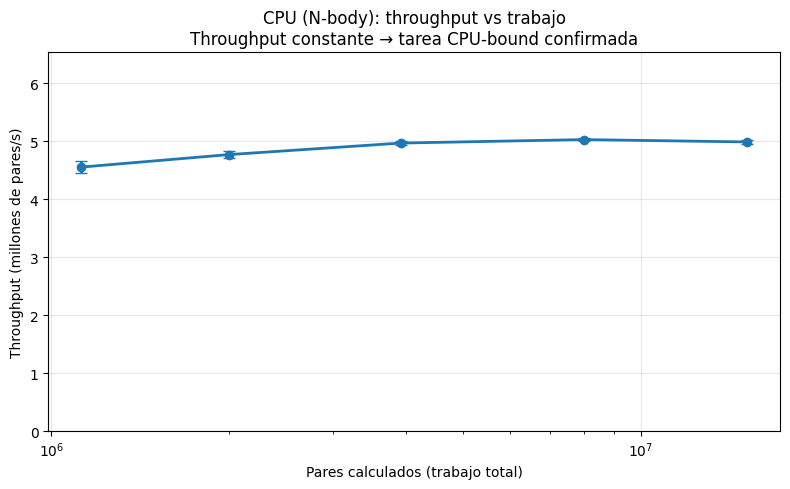

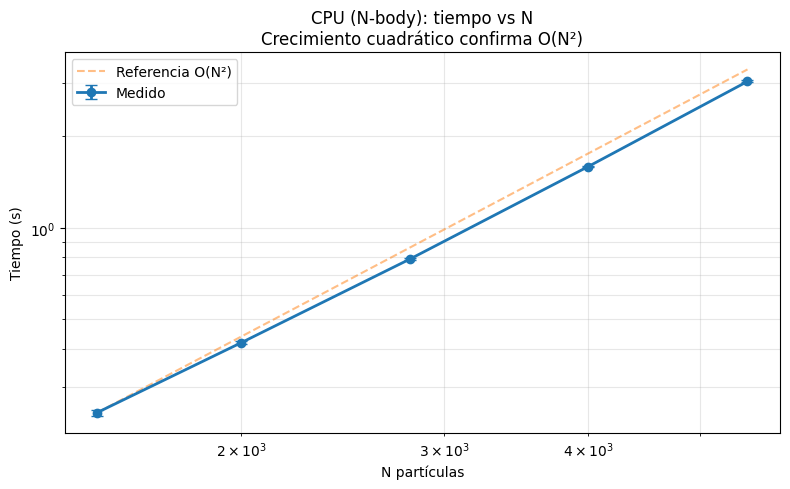

In [12]:
graficar_cpu(df_cpu)


**Conclusión:** El throughput se mantiene aproximadamente constante (~4.5-5.0 M 
pares/s) a lo largo de los 5 tamaños probados, con apenas ~12% de variación entre 
el menor y el mayor. Esa invariancia es la firma esperada de una tarea CPU-bound: 
el cuello de botella es la capacidad aritmética del procesador, no la memoria ni 
el almacenamiento. Las barras de error apenas visibles indican mediciones 
consistentes entre repeticiones, coherente con la efectividad del cooldown de 
10 s para mitigar thermal throttling.

La curva medida sigue prácticamente paralela a la referencia 
O(N²) en escala log-log, con la pendiente real ligeramente por debajo del ideal. 
Esto sugiere que la implementación se comporta consistentemente con el análisis 
asintótico del algoritmo N-body naive. La leve discrepancia respecto al ideal 
teórico (~10%) es atribuible al overhead constante del intérprete que no escala 
con N², y que pesa relativamente más en los tamaños chicos.

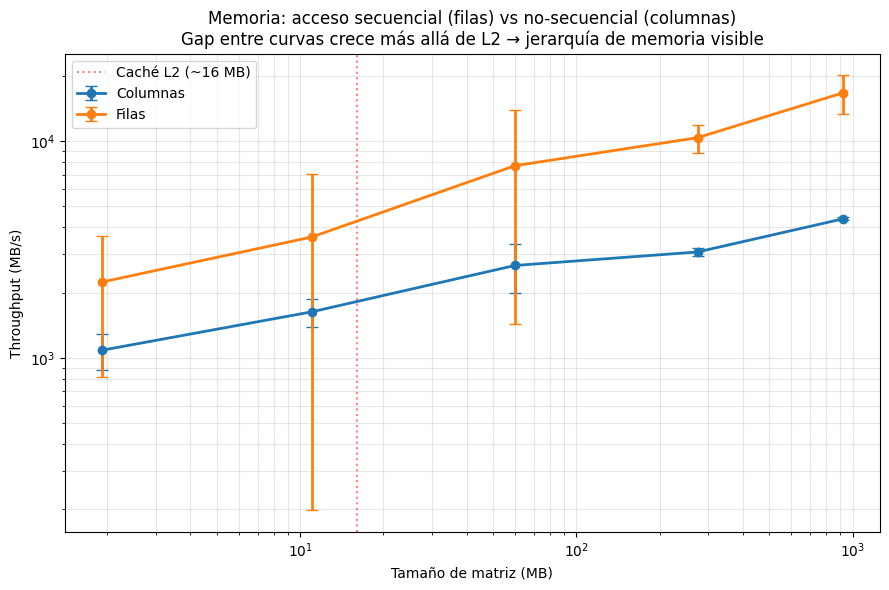

In [13]:
graficar_memoria(df_mem)


**Conclusión:** El acceso por filas supera al acceso por columnas en todo el 
rango medido. El gap entre ambas curvas crece de aproximadamente 2× (a 1.9 MB) 
hasta ~3.8× (a 923 MB), pasando por la frontera de caché L2 (~16 MB). Este 
crecimiento progresivo del gap es consistente con la hipótesis de jerarquía 
de memoria: cuando el array supera la capacidad de la caché, el acceso 
no-contiguo sufre cache misses crecientes mientras el secuencial sigue 
beneficiándose del prefetcher. Las barras de error amplias en los tamaños 
chicos reflejan el overhead del intérprete dominando mediciones de milisegundos.

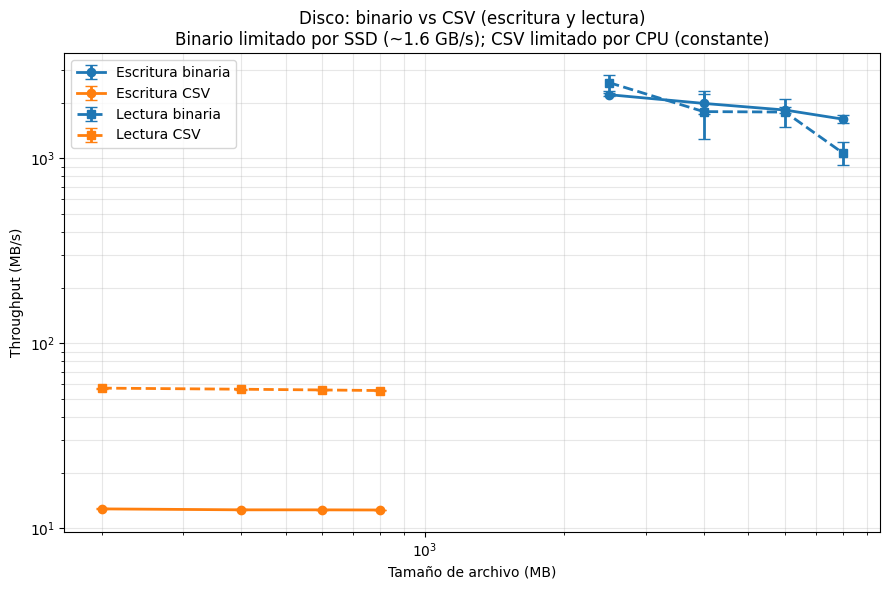

In [14]:
graficar_disco(df_disco)

**Conclusión:** Los dos pares de curvas (binario en azul, CSV en naranja) están 
separados por aproximadamente dos órdenes de magnitud. El binario opera entre 
1000-3000 MB/s y decae con el tamaño del archivo, convergiendo hacia el 
throughput sostenido del SSD para archivos grandes (≈ 1.6 GB/s en escritura). 
El CSV, en cambio, se mantiene plano independientemente del tamaño — firma de 
un proceso CPU-bound: la diferencia no es del dispositivo de almacenamiento 
sino del costo de serialización a texto. Esta observación justifica empíricamente 
la preferencia por formatos binarios columnares (Parquet) sobre CSV en pipelines 
Big Data, decisión adoptada en el Ejercicio 4 de esta evaluación.